In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('./../../data/all_keywords_merged.csv')

In [9]:
df.columns

Index(['keyword', 'source_file', 'asin', 'item_name', 'brand', 'image_count',
       'main_image_url', 'has_aplus', 'has_brand_story', 'review_count',
       'avg_rating', 'bsr_best', 'bsr_paths', 'units_per_month',
       'sales_velocity_daily', 'product_url', 'image_list'],
      dtype='object')

In [20]:
image_url_col = df['main_image_url']

In [21]:
image_url_col.iloc[0]

'https://m.media-amazon.com/images/I/31S4tOQj4SL.jpg'

# From Dylan: 
I worked on finding labels for the images since I think its going to be the strongest points. You guys can decide to use this notebook as a basis to further go deeper into the images. Do not alter this notebook as I may continue working on it. Create a new one adjacent to this one with your name.

I decided to try to get these:
- Clutter vs. Simplicity: segmentation models (detect background %), edge density, number of distinct color clusters.**DONE: ADDED TO DF**
- Presence of Text: many low-quality sellers add text like “BEST DEAL” or “50% OFF.” Best sellers often don’t use text overlays on the main image. Tesseract, EasyOCR, label is has_text. **DONE: no text in images**
- Composition & Focus: we will need AI for this and image detection. 1 object (main product) is usually better. Use object detection models (YOLO, Faster R-CNN) or just bounding-box heuristics. Might be unfeasible but worth trying.
- Image Quality Basics: of cours:  sharpness / focus,  brightness / exposure, contrast, saturation / color vibrance, noise / compression artifacts.
- Product Visibility: % of image covered by product. Cropped vs. fully visible. Overlapping/occluded? Maybe this is the ratio of product bounding box to total image.
- Color and Aesthetic Features: Too many competing colors implies cluttered. Harmonious palette may be professional. Extract color histograms / clustering (k-means?)

I decided to use ChatGPT for the image processing, specially color processing. If you're interested in learning more about it (because your career demands it), take your time to learn it properly.

In [22]:
import os, io, asyncio, random, hashlib
import aiohttp
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import cv2

from sklearn.cluster import KMeans


/opt/anaconda3/envs/amazon-forecast/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
USER_AGENT = (
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
    "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0 Safari/537.36"
)

def safe_name_from_url(url: str) -> str:
    h = hashlib.md5(url.encode("utf-8")).hexdigest()[:16]
    base = url.split("/")[-1].split("?")[0]
    ext = ".jpg" if "." not in base else f".{base.split('.')[-1]}"
    return f"{h}{ext}"

async def fetch_one(session, url, save_dir, sem):
    name = safe_name_from_url(url)
    out_path = os.path.join(save_dir, name)
    if os.path.exists(out_path):
        return out_path

    headers = {"User-Agent": USER_AGENT, "Accept": "image/avif,image/webp,image/*,*/*;q=0.8"}
    async with sem:
        for attempt in range(4):
            try:
                async with session.get(url, headers=headers, timeout=aiohttp.ClientTimeout(total=20)) as r:
                    if r.status != 200:
                        await asyncio.sleep(0.7 * (attempt + 1))
                        continue
                    data = await r.read()
                    img = Image.open(io.BytesIO(data)).convert("RGB")
                    os.makedirs(save_dir, exist_ok=True)
                    img.save(out_path, format="JPEG", quality=95)
                    return out_path
            except Exception:
                await asyncio.sleep(0.7 * (attempt + 1))
        return None

async def download_all(urls, save_dir="images_amz", max_concurrency=8):
    sem = asyncio.Semaphore(max_concurrency)
    conn = aiohttp.TCPConnector(limit=0, ssl=False)
    async with aiohttp.ClientSession(connector=conn) as session:
        tasks = [fetch_one(session, u, save_dir, sem) for u in urls]
        results = []
        for f in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Downloading"):
            results.append(await f)
    return results


In [ ]:
import nest_asyncio, asyncio
nest_asyncio.apply()

urls = df["main_image_url"].dropna().tolist()
paths = asyncio.run(download_all(urls, save_dir="images_amz", max_concurrency=8))

Downloading:   0%|          | 0/17363 [00:00<?, ?it/s]/opt/anaconda3/envs/amazon-forecast/lib/python3.10/asyncio/tasks.py:270: RuntimeWarning: coroutine 'download_all' was never awaited
  self.__wakeup, context=self._context)
Downloading: 100%|██████████| 17363/17363 [13:02<00:00, 22.20it/s] 


ValueError: Length of values (17363) does not match length of index (17375)

In [28]:
import os, hashlib
import numpy as np
import pandas as pd

def expected_path_from_url(url, save_dir="images_amz"):
    if pd.isna(url):
        return np.nan
    base = url.split("/")[-1].split("?")[0]
    ext = ".jpg" if "." not in base else f".{base.split('.')[-1]}"
    name = hashlib.md5(url.encode("utf-8")).hexdigest()[:16] + ext
    path = os.path.join(save_dir, name)
    return path if os.path.exists(path) else np.nan

df["image_path"] = df["main_image_url"].apply(expected_path_from_url)


In [ ]:
import numpy as np, cv2, pandas as pd
from PIL import Image
from sklearn.cluster import KMeans

def load_cv2(path):
    data = np.fromfile(path, dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR) # BGR uint8

def edge_density(img_bgr, low=100, high=200):
    if img_bgr is None: return np.nan
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape[:2]
    edges = cv2.Canny(gray, threshold1=low, threshold2=high)
    return float(np.count_nonzero(edges)) / float(h*w + 1e-9)

def background_fractions(img_bgr):
    if img_bgr is None:
        return dict(bg_white_pct=np.nan, bg_neutral_pct=np.nan)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    H,S,V = cv2.split(hsv)
    Sf, Vf = S.astype(np.float32)/255.0, V.astype(np.float32)/255.0
    white_mask   = (Vf > 0.95) & (Sf < 0.10) # bright and low saturation
    neutral_mask = (Sf < 0.12) # low saturation = neutral bg
    return dict(
        bg_white_pct=float(np.mean(white_mask)),
        bg_neutral_pct=float(np.mean(neutral_mask)),
    )

def palette_complexity(img_bgr, K=5, sample_px=64*64, significant=0.05):
    if img_bgr is None:
        return dict(n_clusters_sig=np.nan, color_entropy=np.nan, largest_cluster_pct=np.nan)

    h, w = img_bgr.shape[:2]
    scale = max(1, int(np.sqrt((h*w)/sample_px)))
    small = cv2.resize(img_bgr, (w//scale, h//scale), interpolation=cv2.INTER_AREA)

    lab = cv2.cvtColor(small, cv2.COLOR_BGR2LAB).reshape(-1, 3).astype(np.float32)
    km = KMeans(n_clusters=K, n_init=5, random_state=42)
    labels = km.fit_predict(lab)
    counts = np.bincount(labels, minlength=K).astype(np.float32)
    weights = counts / counts.sum()

    n_clusters_sig = int(np.sum(weights >= significant))
    eps = 1e-12
    color_entropy = -np.sum(weights * np.log(weights + eps)) / np.log(K + eps)  # normalized [0,1]
    largest_cluster_pct = float(weights.max())

    return dict(
        n_clusters_sig=n_clusters_sig,
        color_entropy=float(color_entropy),
        largest_cluster_pct=largest_cluster_pct
    )

def clutter_features_for_path(path):
    try:
        img = load_cv2(path)
        ed = edge_density(img)
        bg = background_fractions(img)
        pal = palette_complexity(img, K=5)
        return dict(
            image_path=path,
            edge_density=ed,
            bg_white_pct=bg["bg_white_pct"],
            bg_neutral_pct=bg["bg_neutral_pct"],
            n_clusters_sig=pal["n_clusters_sig"],
            color_entropy=pal["color_entropy"],
            largest_cluster_pct=pal["largest_cluster_pct"],
        )
    except Exception:
        return dict(
            image_path=path,
            edge_density=np.nan,
            bg_white_pct=np.nan,
            bg_neutral_pct=np.nan,
            n_clusters_sig=np.nan,
            color_entropy=np.nan,
            largest_cluster_pct=np.nan,
        )


In [31]:
from tqdm.auto import tqdm

have = df["image_path"].notna()
feat_rows = [clutter_features_for_path(p) for p in tqdm(df.loc[have, "image_path"], desc="Clutter features")]
df_feats = pd.DataFrame(feat_rows)


Clutter features: 100%|██████████| 17334/17334 [10:50<00:00, 26.63it/s]


In [32]:
for col in ["edge_density","n_clusters_sig","color_entropy","bg_white_pct","bg_neutral_pct","largest_cluster_pct"]:
    m = df_feats[col].mean()
    s = df_feats[col].std(ddof=0) + 1e-9 #small number so we dont divide by 0 in some cases.
    df_feats[col+"_z"] = (df_feats[col] - m)/s #this is the zscore (stats)

df_feats["clutter_score"] = ( #higher = more clutter
    + 0.45 * df_feats["edge_density_z"]
    + 0.30 * df_feats["n_clusters_sig_z"]
    + 0.25 * df_feats["color_entropy_z"]
    - 0.30 * df_feats["bg_white_pct_z"]
    - 0.20 * df_feats["bg_neutral_pct_z"]
    - 0.15 * df_feats["largest_cluster_pct_z"]
)

df_model = df.merge(df_feats, on="image_path", how="left")


In [ ]:
pip install pandas numpy matplotlib ultralytics opencv-python-headless pillow torch torchvision tqdm

In [66]:
import pandas as pd
import numpy as np
df_model = pd.read_csv('./df_with_clutter_features.csv')

In [2]:
simple = df_model.sort_values("clutter_score", ascending=True).head(5)
busy   = df_model.sort_values("clutter_score", ascending=False).head(5)

cols = ["image_path","clutter_score","bg_white_pct","largest_cluster_pct","edge_density","n_clusters_sig","color_entropy"]
display(simple[cols])
display(busy[cols])

df_model.to_csv("df_with_clutter_features.csv", index=False)


,image_path,clutter_score,bg_white_pct,largest_cluster_pct,edge_density,n_clusters_sig,color_entropy
11381,images_amz/866237e84fde8a3c.jpg,-3.652532,0.961232,0.950769,0.001007,1.0,0.152908
10264,images_amz/eb58f783c164e724.jpg,-3.601807,0.954870,0.943848,0.001227,1.0,0.173692
9455,images_amz/0e6a40ff8d3a326e.jpg,-3.591841,0.955214,0.947998,0.002823,1.0,0.169502
9595,images_amz/45c033bc7162de66.jpg,-3.585157,0.955205,0.946777,0.002446,1.0,0.174915
9376,images_amz/96e730aaf104e216.jpg,-3.567192,0.954709,0.941895,0.002303,1.0,0.185530


,image_path,clutter_score,bg_white_pct,largest_cluster_pct,edge_density,n_clusters_sig,color_entropy
8158,images_amz/df1a7d5e92f416a2.jpg,4.772736,0.020349,0.248663,0.240882,5.0,0.966516
16981,images_amz/9ce546164ec235be.jpg,4.705153,0.132536,0.296201,0.254964,5.0,0.942215
6601,images_amz/1edd23725c057b44.jpg,4.670320,0.051152,0.335786,0.241129,5.0,0.951495
6208,images_amz/c9c9f4849d181e55.jpg,4.667717,0.109912,0.232692,0.241584,5.0,0.996853
17694,images_amz/b922bd22bca88a1c.jpg,4.622601,0.125244,0.301441,0.249596,5.0,0.955061


In [3]:
df_model.select_dtypes(np.number).corr()['bsr_best']

image_count             -0.063141
review_count                  NaN
avg_rating                    NaN
bsr_best                 1.000000
units_per_month               NaN
sales_velocity_daily          NaN
edge_density            -0.002961
bg_white_pct            -0.022585
bg_neutral_pct          -0.029610
n_clusters_sig           0.002489
color_entropy            0.000001
largest_cluster_pct     -0.004283
edge_density_z          -0.002961
n_clusters_sig_z         0.002489
color_entropy_z          0.000001
bg_white_pct_z          -0.022585
bg_neutral_pct_z        -0.029610
largest_cluster_pct_z   -0.004283
clutter_score            0.009661
Name: bsr_best, dtype: float64

I went thru the images. None have text.

In [9]:
import torch, os
assert torch.cuda.is_available(), "PyTorch can't see your GPU"
print("GPU:", torch.cuda.get_device_name(0))
torch.backends.cudnn.benchmark = True  # speed on fixed-size inputs
yolo_device = 0  # CUDA GPU id 0



GPU: NVIDIA A40


In [14]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")   # or 'yolov8s.pt' if you have headroom

have = df_model["image_path"].notna()
paths = df_model.loc[have, "image_path"].tolist()

# one quick pass to ensure everything is OK (weights downloaded, paths valid)
test_path = next(p for p in paths if isinstance(p, str))
_ = model.predict(source=[test_path],
                  imgsz=640, conf=0.25, iou=0.45,
                  device=yolo_device, workers=0,
                  stream=False, half=True, verbose=True)
print("Warmup OK.")


0: 640x640 1 mouse, 4.6ms
Speed: 1.8ms preprocess, 4.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Warmup OK.


In [11]:
def iou_xyxy(a, b):
    # a,b: [x1,y1,x2,y2]
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1, inter_y1 = max(ax1, bx1), max(ay1, by1)
    inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
    inter_w, inter_h = max(0, inter_x2 - inter_x1), max(0, inter_y2 - inter_y1)
    inter = inter_w * inter_h
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter + 1e-9
    return inter / union

def center_offset_norm(box, w, h):
    x1, y1, x2, y2 = box
    cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
    dx, dy = cx - (w/2.0), cy - (h/2.0)
    # normalized by image diagonal (so result in [0, ~0.5])
    return math.sqrt(dx*dx + dy*dy) / math.sqrt(w*w + h*h)

def grabcut_foreground_ratio_and_center(img_bgr, rect_margin=0.05, iters=3):
    """Fallback when detector finds nothing. Rough single-foreground estimate."""
    h, w = img_bgr.shape[:2]
    # rectangle slightly inset from the image border
    x = int(w*rect_margin); y = int(h*rect_margin)
    rw = int(w*(1-2*rect_margin)); rh = int(h*(1-2*rect_margin))
    rect = (x, y, rw, rh)

    mask = np.zeros((h, w), np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)
    cv2.grabCut(img_bgr, mask, rect, bgdModel, fgdModel, iters, cv2.GC_INIT_WITH_RECT)
    # probable/definite foreground are 1 & 3
    fg_mask = np.where((mask==1) | (mask==3), 1, 0).astype(np.uint8)
    fg_ratio = float(fg_mask.sum()) / float(h*w + 1e-9)

    # center of mass of foreground (if any)
    if fg_mask.sum() > 0:
        ys, xs = np.nonzero(fg_mask)
        cx, cy = xs.mean(), ys.mean()
        dx, dy = cx - (w/2.0), cy - (h/2.0)
        center_off = math.sqrt(dx*dx + dy*dy) / math.sqrt(w*w + h*h)
    else:
        center_off = 0.0
    return fg_ratio, center_off



In [20]:
import os, time, numpy as np, pandas as pd, cv2, torch
from ultralytics import YOLO
from tqdm.auto import tqdm

assert torch.cuda.is_available()
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")  # tiny speedup on Ampere+
device = 0

model = YOLO("yolov8n.pt")
IMGSZ      = 384      # ↓ from 640; very big speedup, usually enough for our features
GPU_BATCH  = 128      # try 128; increase/decrease if VRAM errs
PATH_CHUNK = 512      # fewer Python calls; make this large
CONF       = 0.35     # raise conf → fewer boxes/NMS work
IOU        = 0.45

def exists(p): 
    try: return os.path.getsize(p) > 0
    except: return False

# keep only good paths
paths = [p for p in paths if isinstance(p, str) and exists(p)]

rows = []
pbar = tqdm(total=len(paths), desc="YOLO images (fast)")
for s in range(0, len(paths), PATH_CHUNK):
    batch_paths = paths[s:s+PATH_CHUNK]
    res = model.predict(
        source=batch_paths,
        imgsz=IMGSZ,
        conf=CONF,
        iou=IOU,
        device=device,
        workers=0,        # notebooks: 0; in scripts try 4–8
        stream=False,
        batch=GPU_BATCH,  # actual GPU minibatch
        half=True,        # FP16 on CUDA
        verbose=False,
        save=False, show=False, agnostic_nms=False
    )
    for r in res:
        pbar.update(1)
        p = r.path; h, w = r.orig_shape; tot_area = float(h*w)
        if (r.boxes is None) or (len(r.boxes) == 0):
            rows.append(dict(
                image_path=p, n_objects=0, category_diversity=0, has_person=0,
                sum_box_ratio=0.0, product_box_ratio=0.0, center_offset_main=0.0,
                mean_iou_overlap=0.0, fg_ratio_grabcut=0.0, center_offset_grabcut=0.0
            ))
            continue

        b = r.boxes
        xyxy = b.xyxy.detach().to("cpu").numpy()
        cls  = b.cls.detach().to("cpu").numpy().astype(int)

        areas  = (xyxy[:,2]-xyxy[:,0])*(xyxy[:,3]-xyxy[:,1])
        ratios = areas/(tot_area+1e-9)
        sum_ratio = float(ratios.sum())
        main_idx  = int(areas.argmax())
        prod_ratio = float(ratios[main_idx])

        # helpers you already defined:
        # center_offset_norm, iou_xyxy
        center_off = center_offset_norm(xyxy[main_idx], w, h)

        n = len(xyxy)
        if n > 1:
            ious = []
            for i in range(n):
                for j in range(i+1, n):
                    ious.append(iou_xyxy(xyxy[i], xyxy[j]))
            mean_iou = float(np.mean(ious)) if ious else 0.0
        else:
            mean_iou = 0.0

        names = model.names
        cls_names = [names[int(c)] for c in cls]
        has_person = int("person" in cls_names)
        category_diversity = int(len(set(cls_names)))

        rows.append(dict(
            image_path=p,
            n_objects=int(n),
            category_diversity=category_diversity,
            has_person=has_person,
            sum_box_ratio=sum_ratio,
            product_box_ratio=prod_ratio,
            center_offset_main=center_off,
            mean_iou_overlap=mean_iou,
            fg_ratio_grabcut=0.0,
            center_offset_grabcut=0.0
        ))

pbar.close()
df_det = pd.DataFrame(rows)


YOLO images (fast):   0%|          | 0/19008 [00:00<?, ?it/s]

In [35]:
df_det.head()

,image_path,n_objects,category_diversity,has_person,sum_box_ratio,product_box_ratio,center_offset_main,mean_iou_overlap,fg_ratio_grabcut,center_offset_grabcut
0,/workspace/Forecasting-Amazon-Sales-with-Multi...,1,1,0,0.601317,0.601317,0.010518,0.0,0.0,0.0
1,/workspace/Forecasting-Amazon-Sales-with-Multi...,0,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,/workspace/Forecasting-Amazon-Sales-with-Multi...,0,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0
3,/workspace/Forecasting-Amazon-Sales-with-Multi...,0,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,/workspace/Forecasting-Amazon-Sales-with-Multi...,0,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0


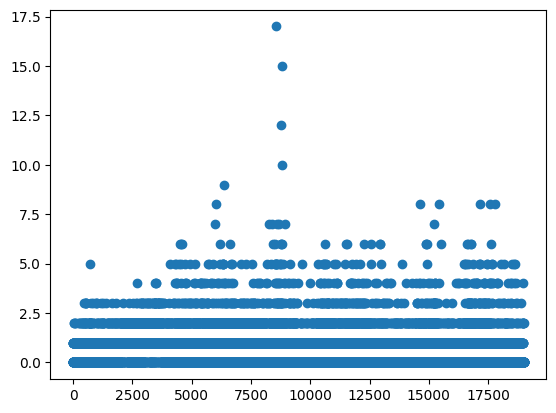

In [40]:
import matplotlib.pyplot as plt
plt.scatter(df_det.index, df_det['n_objects'])

In [54]:
prefix = "/workspace/Forecasting-Amazon-Sales-with-Multimodal-Data/notebooks/02-Image Analysis/"

# Option 1: str.replace
df_det["image_path"] = df_det["image_path"].str.replace(prefix, "", regex=False)

# Option 2: str.removeprefix (Python 3.9+)
df_det["image_path"] = df_det["image_path"].str.removeprefix(prefix)


In [78]:
def inplace_update_from_det(df_model: pd.DataFrame, df_det: pd.DataFrame, key_col="image_path"):
    """
    Align df_model rows with df_det on `key_col` and copy all columns from df_det into df_model.
    - If a column already exists in df_model, overwrite it.
    - If a column does not exist, create it.
    - Rows in df_model without a match in df_det remain unchanged (NaN if new col).
    - No new rows are added.
    - If df_det has duplicate keys, the *last* occurrence wins.
    """
    # 1) deduplicate df_det on the key
    det_last = (
        df_det
        .dropna(subset=[key_col])
        .drop_duplicates(subset=[key_col], keep="last")
        .set_index(key_col)
    )

    # 2) for every column in det (except key), map into df_model
    for c in det_last.columns:
        df_model[c] = df_model[key_col].map(det_last[c])

    return df_model


In [79]:
df_model = inplace_update_from_det(df_model, df_det, key_col="image_path")


In [80]:
df_model["product_coverage"] = df_model["product_box_ratio"].fillna(0.0)
fallback = df_model["product_coverage"] == 0.0
df_model.loc[fallback, "product_coverage"] = df_model.loc[fallback, "fg_ratio_grabcut"].fillna(0.0)

df_model["center_offset"] = df_model["center_offset_main"].fillna(0.0)
fallback2 = df_model["center_offset"] == 0.0
df_model.loc[fallback2, "center_offset"] = df_model.loc[fallback2, "center_offset_grabcut"].fillna(0.0)

if "bg_white_pct" in df_model.columns:
    df_model["white_bg_ok"] = (df_model["bg_white_pct"] >= 0.85).astype("Int8")


In [94]:
df_model['image_path']

0        images_amz/3347156682c8f0ca.jpg
1        images_amz/e7c4b57eac5ca716.jpg
2        images_amz/e7c4b57eac5ca716.jpg
3        images_amz/a114c60191cfaf62.jpg
4        images_amz/a114c60191cfaf62.jpg
                      ...               
19044    images_amz/116571ed183ac133.jpg
19045    images_amz/e3e25738baf8b982.jpg
19046    images_amz/6f8328802945bc64.jpg
19047    images_amz/5bae15f9e5ecc844.jpg
19048    images_amz/9077ea2f246e7ce9.jpg
Name: image_path, Length: 19049, dtype: object

In [82]:
df_det['image_path']

0        images_amz/3347156682c8f0ca.jpg
1        images_amz/e7c4b57eac5ca716.jpg
2        images_amz/e7c4b57eac5ca716.jpg
3        images_amz/a114c60191cfaf62.jpg
4        images_amz/a114c60191cfaf62.jpg
                      ...               
19003    images_amz/116571ed183ac133.jpg
19004    images_amz/e3e25738baf8b982.jpg
19005    images_amz/6f8328802945bc64.jpg
19006    images_amz/5bae15f9e5ecc844.jpg
19007    images_amz/9077ea2f246e7ce9.jpg
Name: image_path, Length: 19008, dtype: object

In [76]:
df_det.head()

,image_path,n_objects,category_diversity,has_person,sum_box_ratio,product_box_ratio,center_offset_main,mean_iou_overlap,fg_ratio_grabcut,center_offset_grabcut
0,images_amz/3347156682c8f0ca.jpg,1,1,0,0.601317,0.601317,0.010518,0.0,0.0,0.0
1,images_amz/e7c4b57eac5ca716.jpg,0,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,images_amz/e7c4b57eac5ca716.jpg,0,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0
3,images_amz/a114c60191cfaf62.jpg,0,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,images_amz/a114c60191cfaf62.jpg,0,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0


In [95]:
df_model = df_model.dropna(axis=1, how="all")

In [97]:
df_model.to_csv('yolo_udpate_data.csv')